In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
from pypalettes import load_cmap
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [9]:
df = pd.read_parquet(r"C:\Users\aguru\Downloads\taxi-trips-summer.parquet")

df = (
    df.loc[df["pickup_borough"] != "Unknown"]
    .groupby("pickup_borough", observed=True)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="num_trips")
    .assign(
        pct=lambda x: x["num_trips"] / x["num_trips"].sum() * 100
    )
)

df

,pickup_borough,num_trips,pct
0,Manhattan,9255118,84.233440
1,Queens,1173381,10.679271
2,Brooklyn,459634,4.183259
3,Bronx,96834,0.881314
4,EWR,1499,0.013643
5,Staten Island,997,0.009074


# Bar Chart

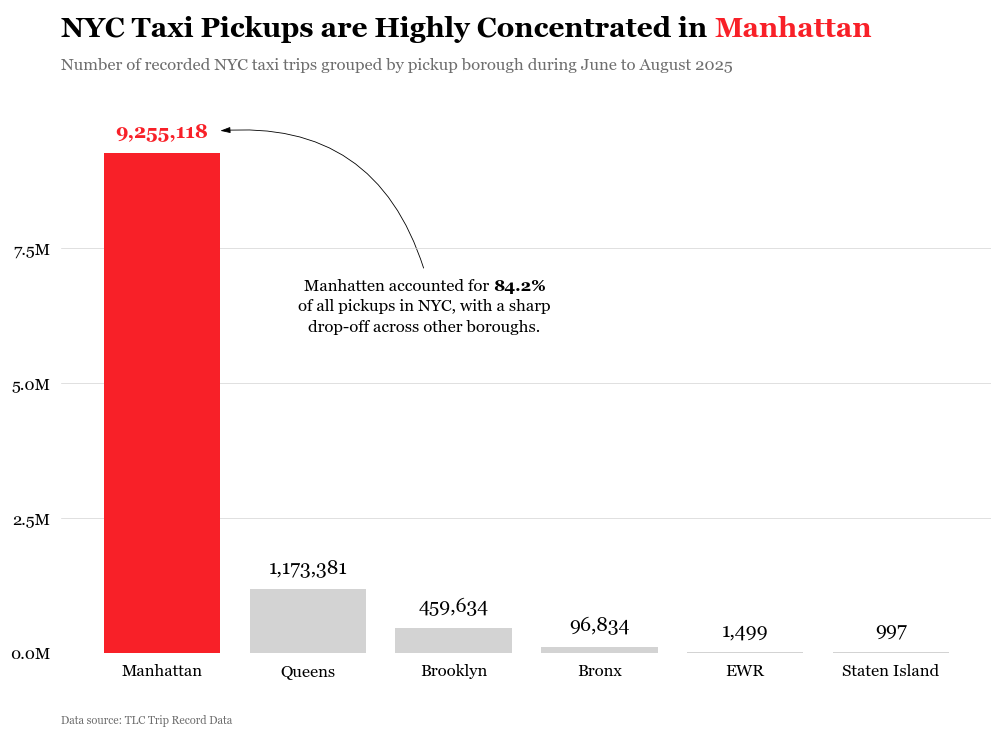

In [75]:
# define colour palette
cmap = load_cmap("groudon")
colours = cmap.colors

# identify borough with highest pickups
highlight_borough = df.loc[df["num_trips"].idxmax(), "pickup_borough"]

# map colours: highlight Manhattan, mute others
highlight_colour = colours[1]
colours_df = (df["pickup_borough"] == highlight_borough).map({
    True: highlight_colour,
    False: "lightgrey"
})

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# refine appearance of axes
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(
    axis="both",
    length=0,
    pad=8,
    labelsize=12
)

# limit number of y-axis ticks
ax.yaxis.set_major_locator(
    mticker.MaxNLocator(nbins=4)
)

# format y-axis in millions
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

# gridlines
ax.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.5
)

# plot bar chart
ax.bar(
    x=df["pickup_borough"],
    height=df["num_trips"],
    color=colours_df,
    zorder=2
)

# annotate bars (in millions)
for i, (borough, value) in enumerate(zip(df["pickup_borough"], df["num_trips"])):
    ax.text(
        x=i,
        y=value + (df["num_trips"].max() * 0.025),
        # s=f"{value/1e6:.1f}M",
        s=f"{value:,.0f}",
        va="bottom",
        ha="center",
        fontsize=14,
        weight="bold" if borough == highlight_borough else None,
        color=highlight_colour if borough == highlight_borough else "black"
    )

# arrow coordinates (point to Manhattan bar)
idx = df["num_trips"].idxmax()
y_max = df["num_trips"].max()
highlight_pct = df.loc[idx, "pct"]
x_head, y_head = idx + .38, y_max * 1.045
x_tail, y_tail = idx + 1.8, y_max * .75 # adjust for placement

ax.set_ylim(0, y_max * 1.08)    # fix y-axis limits (prevents large scaling issues)

# draw arrow
ax_arrow(
    head_position=(x_head, y_head),
    tail_position=(x_tail, y_tail * 1.02),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=0.4,
    width=0.6
)

# annotation text with highlighted percentage
ax_text(
    x=x_tail, y=y_tail,
    s=f"Manhatten accounted for <{highlight_pct:.1f}%>\nof all pickups in NYC, with a sharp\ndrop-off across other boroughs.",
    highlight_textprops=[
        {"weight": "bold"}
    ],
    fontsize=12,
    ha="center",
    va="top",
    textalign="center"
)

# title with highlight
x_title, y_title = 0.125, 1.02
fig_text(
    x=x_title, y=y_title,
    s=f"NYC Taxi Pickups are Highly Concentrated in <{highlight_borough}>",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# subtitle
fig.text(
    x=x_title, y=y_title * 0.925,
    s="Number of recorded NYC taxi trips grouped by pickup borough during June to August 2025",
    size=12,
    color="#6e6e6e"
)

# caption
fig.text(
    x=x_title,
    y=0.005,
    s="Data source: TLC Trip Record Data",
    ha="left",
    va="bottom",
    fontsize=8,
    color="#6e6e6e",
)

plt.savefig(
    "../images/trips_by_pickup_borough.svg",
    bbox_inches="tight"
)

plt.show()